# Escape Time around a Hyperbolic Fixed Point

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.integrator.integrate import FastSitnikovSimulation
from src.utils.plotting import plot_position_sitnikov, polar_scatter

In [2]:
e = 0.5
sim = FastSitnikovSimulation(e = e)

With the phi_fast implementation, there is no numerical fixed point (v,2pi) = phi_fast(v,0). So I will accept some value of t=0 which is allowed to be lower.

In [87]:
# Two-stage optimization:
# 1) brentq seed at t=0 enforcing t_out = 2*pi
# 2) 2D refinement in (v, t) minimizing residuals
import scipy.optimize as optimize

t0 = 0.0
period = 2.0 * np.pi

def periodic_delta(x, ref, p=period):
    return ((float(x) - float(ref) + 0.5 * p) % p) - 0.5 * p

def phi_fast_safe(v, t, t_max=200.0):
    v_out, t_out = sim.phi_fast(v=float(v), t=float(t), t_max=t_max, return_mod_period=False)
    return v_out, t_out

# ---------- Stage 1: 1D brentq at t=0 ----------
def time_to_2pi_error(v):
    _, t_out = phi_fast_safe(v=v, t=t0, t_max=200.0)
    if t_out is None:
        return np.nan
    return float(t_out) - period

a, b = 0.5, 2.6

v_hyper = optimize.brentq(time_to_2pi_error, a, b, xtol=1e-14, rtol=1e-14, maxiter=1000)
t_hyper = t0

## We compute the unstable manifold

In [88]:
# Refine a local fixed point of phi near the hyperbolic point by minimizing
# ||(v, t) - phi(v, t)||_2.

def phi_fast_safe_local(v, t, t_max=200.0):
    v_out, t_out = sim.phi_fast(v=float(v), t=float(t), t_max=t_max, return_mod_period=False)
    return v_out, t_out

def residual_vector_vt_fwd(x):
    v = float(x[0])
    t = float(x[1])
    v_out, t_out = phi_fast_safe_local(v=v, t=t, t_max=200.0)

    if v_out is None or t_out is None:
        return np.array([1e3, 1e3], dtype=float)

    dv = float(v_out) - v
    dt = periodic_delta(t_out, t)
    return np.array([dv, dt], dtype=float)

delta_v = 5e-3
delta_t = 5e-3
lb = np.array([v_hyper - delta_v, t_hyper - delta_t], dtype=float)
ub = np.array([v_hyper + delta_v, t_hyper + delta_t], dtype=float)

refined_fwd = optimize.least_squares(
    residual_vector_vt_fwd,
    x0=np.array([float(v_hyper), float(t_hyper)], dtype=float),
    bounds=(lb, ub),
    xtol=1e-14,
    ftol=1e-14,
    gtol=1e-14,
    max_nfev=15000,
    method="trf",
)

v_center_unstable = float(refined_fwd.x[0])
t_center_unstable = float(refined_fwd.x[1])
r_center_unstable = residual_vector_vt_fwd([v_center_unstable, t_center_unstable])

print(f"Unstable center near hyperbolic point: v = {v_center_unstable:.16f}, t = {t_center_unstable:.16e}")
print(f"phi residuals at unstable center: dv = {r_center_unstable[0]:.3e}, dt = {r_center_unstable[1]:.3e}")
print(f"L2 norm = {np.linalg.norm(r_center_unstable):.3e}")

Unstable center near hyperbolic point: v = 2.5491241932335571, t = 1.8820435591105792e-07
phi residuals at unstable center: dv = -1.288e-14, dt = -2.309e-14
L2 norm = 2.644e-14


In [89]:
def wrap_time_to_center(t_values, center, period=2.0 * np.pi):
    t_arr = np.asarray(t_values, dtype=float)
    return center + np.mod(t_arr - center + 0.5 * period, period) - 0.5 * period


def iterate_phi_n(sim, v0, t0, n_iter=3, t_step_max=100.0):
    t_curr = float(t0)
    v_curr = float(v0)

    for _ in range(n_iter):
        v_curr, t_curr = sim.phi_fast(v=v_curr, t=t_curr, t_max=t_step_max, return_mod_period=True)
        if v_curr is None or t_curr is None:
            return None, None

    return t_curr, v_curr

eps = 1e-12
k = 100
n_iter = 6
x_neg = np.linspace(-k*eps, -eps, 50)
x_pos = np.linspace(eps, k*eps, 50)
x_vals = np.concatenate((x_neg, x_pos))

unstable_manifold_t = []
unstable_manifold_v = []

for x in x_vals:
    t_end, v_end = iterate_phi_n(
        sim,
        v_center_unstable,
        t_center_unstable + x,
        n_iter=n_iter,
        t_step_max=100.0,
    )
    if t_end is not None and v_end is not None:
        unstable_manifold_t.append(float(t_end))
        unstable_manifold_v.append(float(v_end))

unstable_manifold_t = np.asarray(unstable_manifold_t, dtype=float)
unstable_manifold_v = np.asarray(unstable_manifold_v, dtype=float)

unstable_manifold_t = wrap_time_to_center(unstable_manifold_t, center=float(t_center_unstable))

print(f"Computed unstable-manifold points: {unstable_manifold_t.size}")

Computed unstable-manifold points: 100


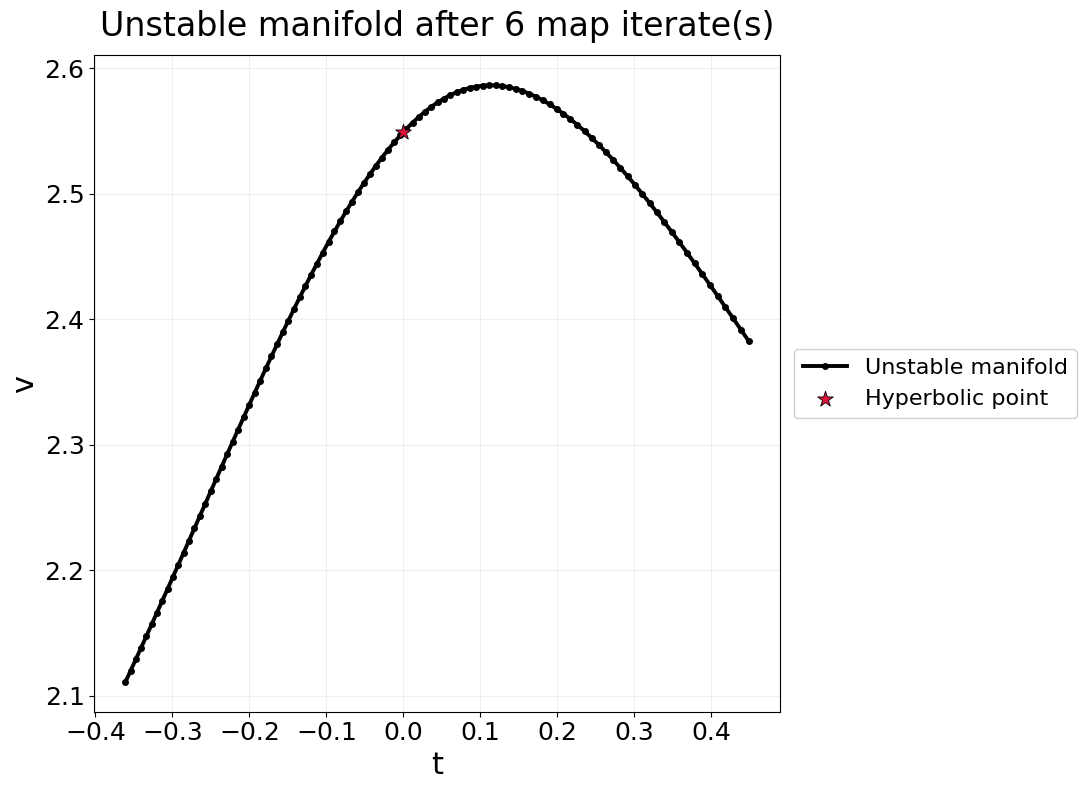

In [90]:
fig, ax = plt.subplots(figsize=(11, 8))

if unstable_manifold_t.size > 1:
    ax.plot(
        unstable_manifold_t,
        unstable_manifold_v,
        color="black",
        linewidth=2.8,
        marker="o",
        markersize=4,
        label=r"Unstable manifold",
    )

ax.scatter(
    [t_hyper],
    [v_hyper],
    s=140,
    c="crimson",
    marker="*",
    edgecolors="k",
    linewidths=0.6,
    zorder=8,
    label="Hyperbolic point",
)

ax.set_title(f"Unstable manifold after {n_iter} map iterate(s)", fontsize=24, pad=14)
ax.set_xlabel("t", fontsize=22)
ax.set_ylabel("v", fontsize=22)
ax.tick_params(axis="both", labelsize=18)
ax.grid(alpha=0.2)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    framealpha=0.95,
    fontsize=16,
    borderaxespad=0.0,
)

fig.tight_layout()
plt.show()

## We also compute the stable manifold

In [84]:
# Refine a local fixed point of phi_inv near the hyperbolic point by minimizing
# ||(v, t) - phi_inv(v, t)||_2.
import scipy.optimize as optimize

period = 2.0 * np.pi

def periodic_delta_inv(x, ref, p=period):
    return ((float(x) - float(ref) + 0.5 * p) % p) - 0.5 * p

def phi_inv_fast_safe(v, t, t_max=200.0):
    v_out, t_out = sim.phi_inv_fast(v=float(v), t=float(t), t_max=t_max, return_mod_period=False)
    return v_out, t_out

def residual_vector_vt_inv(x):
    v = float(x[0])
    t = float(x[1])
    v_out, t_out = phi_inv_fast_safe(v=v, t=t, t_max=200.0)

    if v_out is None or t_out is None:
        return np.array([1e3, 1e3], dtype=float)

    dv = float(v_out) - v
    dt = periodic_delta_inv(t_out, t)
    return np.array([dv, dt], dtype=float)

delta_v = 5e-3
delta_t = 5e-3
lb = np.array([v_hyper - delta_v, t_hyper - delta_t], dtype=float)
ub = np.array([v_hyper + delta_v, t_hyper + delta_t], dtype=float)

refined_inv = optimize.least_squares(
    residual_vector_vt_inv,
    x0=np.array([float(v_hyper), float(t_hyper)], dtype=float),
    bounds=(lb, ub),
    xtol=1e-14,
    ftol=1e-14,
    gtol=1e-14,
    max_nfev=15000,
    method="trf",
)

v_center_stable = float(refined_inv.x[0])
t_center_stable = float(refined_inv.x[1])
r_center_stable = residual_vector_vt_inv([v_center_stable, t_center_stable])

print(f"Stable center near hyperbolic point: v = {v_center_stable:.16f}, t = {t_center_stable:.16e}")
print(f"phi_inv residuals at stable center: dv = {r_center_stable[0]:.3e}, dt = {r_center_stable[1]:.3e}")
print(f"L2 norm = {np.linalg.norm(r_center_stable):.3e}")

Stable center near hyperbolic point: v = 2.5491241932335584, t = -1.8820435708772904e-07
phi_inv residuals at stable center: dv = 1.021e-14, dt = -1.688e-14
L2 norm = 1.973e-14


In [85]:
import importlib
import src.integrator.integrate as integrate_module

integrate_module = importlib.reload(integrate_module)
FastSitnikovSimulation = integrate_module.FastSitnikovSimulation
sim = FastSitnikovSimulation(e=e)


def iterate_phi_inv_n(sim, v0, t0, n_iter=3, t_step_max=100.0):
    t_curr = float(t0)
    v_curr = float(v0)

    for _ in range(n_iter):
        v_curr, t_curr = sim.phi_inv_fast(v=v_curr, t=t_curr, t_max=t_step_max, return_mod_period=True)
        if v_curr is None or t_curr is None:
            return None, None

    return t_curr, v_curr

eps = 1e-12
k = 100
n_iter = 6
x_neg = np.linspace(-k*eps, -eps, 50)
x_pos = np.linspace(eps, k*eps, 50)
x_vals = np.concatenate((x_neg, x_pos))

stable_manifold_t = []
stable_manifold_v = []

for x in x_vals:
    t_end, v_end = iterate_phi_inv_n(
        sim,
        v_center_stable,
        t_center_stable + x,
        n_iter=n_iter,
        t_step_max=100.0,
    )
    if t_end is not None and v_end is not None:
        stable_manifold_t.append(float(t_end))
        stable_manifold_v.append(float(v_end))

stable_manifold_t = np.asarray(stable_manifold_t, dtype=float)
stable_manifold_v = np.asarray(stable_manifold_v, dtype=float)

stable_manifold_t = wrap_time_to_center(stable_manifold_t, center=float(t_center_stable))

print(f"Computed stable-manifold points: {stable_manifold_t.size}")

Computed stable-manifold points: 100


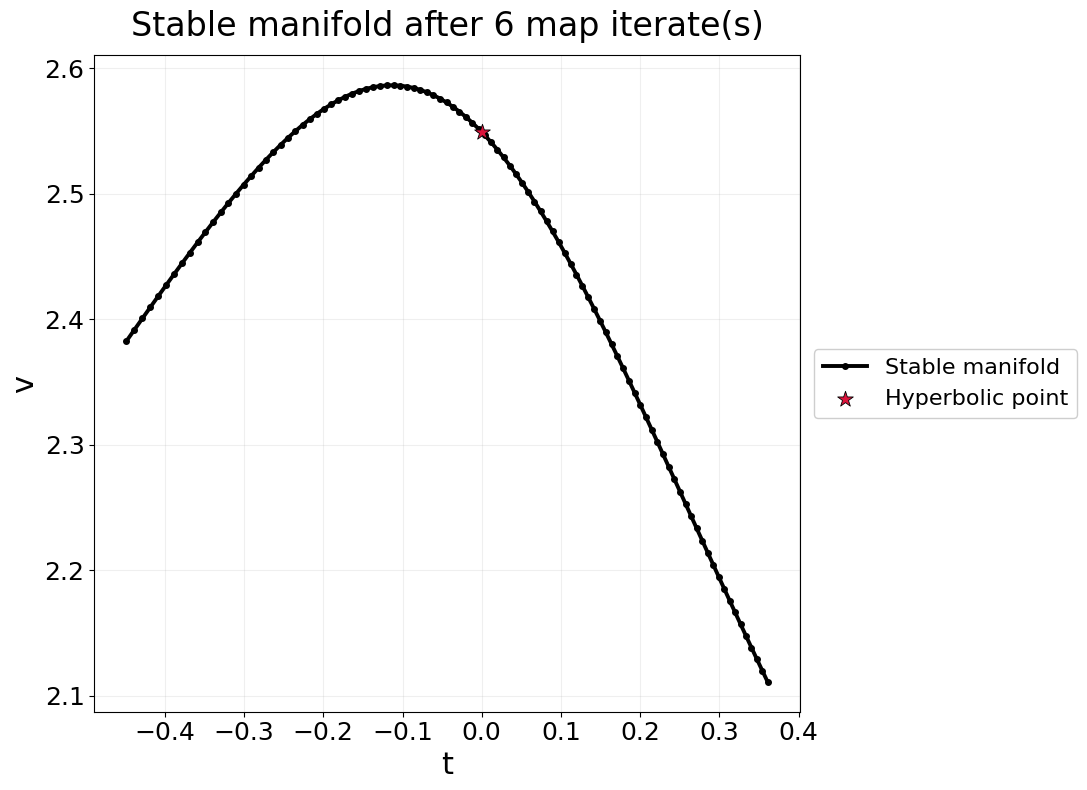

In [86]:
fig, ax = plt.subplots(figsize=(11, 8))

if stable_manifold_t.size > 1:
    ax.plot(
        stable_manifold_t,
        stable_manifold_v,
        color="black",
        linewidth=2.8,
        marker="o",
        markersize=4,
        label="Stable manifold",
    )

ax.scatter(
    [t_hyper],
    [v_hyper],
    s=140,
    c="crimson",
    marker="*",
    edgecolors="k",
    linewidths=0.6,
    zorder=8,
    label="Hyperbolic point",
)

ax.set_title(f"Stable manifold after {n_iter} map iterate(s)", fontsize=24, pad=14)
ax.set_xlabel("t", fontsize=22)
ax.set_ylabel("v", fontsize=22)
ax.tick_params(axis="both", labelsize=18)
ax.grid(alpha=0.2)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    framealpha=0.95,
    fontsize=16,
    borderaxespad=0.0,
)

fig.tight_layout()
plt.show()

## We compute crossings in a grid around the hyperbolic fixed point

In [68]:
N = 33

t_vals = np.linspace(t_hyper - 0.2, t_hyper + 0.2, N)
v_vals = np.linspace(v_hyper - 0.1, v_hyper + 0.1, N)

T, V = np.meshgrid(t_vals, v_vals)
t_grid = T.ravel()
v_grid = V.ravel()

crossings_fn = getattr(sim, "fast_crossings_iterated", None)
if crossings_fn is None:
    crossings_fn = sim.fast_crossings_iterated

escape_crossings = np.array([
    crossings_fn(v=v0, t=t0)
    for t0, v0 in zip(t_grid, v_grid)
], dtype=float)

print(f"Computed {escape_crossings.size} grid points ({N}x{N}).")

Computed 1089 grid points (33x33).


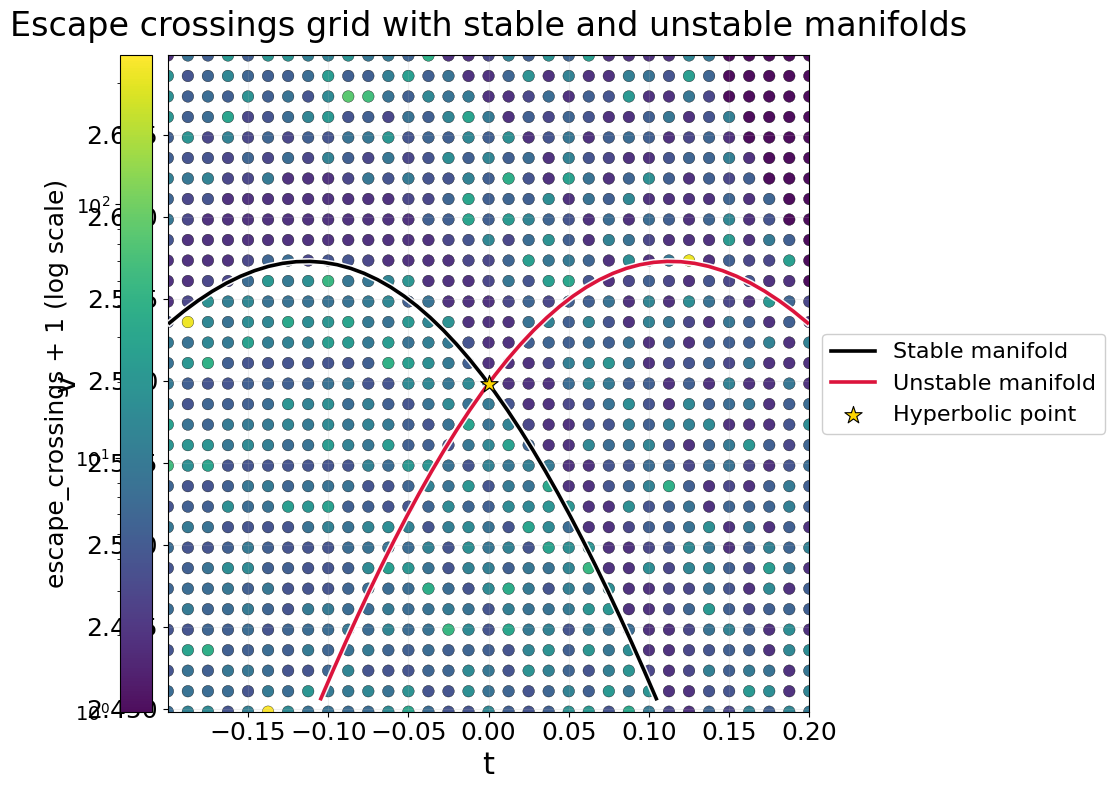

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))

# Grid domain limits (exactly the NxN sampling window)
t_min, t_max = float(np.min(t_vals)), float(np.max(t_vals))
v_min, v_max = float(np.min(v_vals)), float(np.max(v_vals))

# Log color scale for escape crossings (shift by +1 so zero values are valid)
import matplotlib.colors as mcolors
escape_for_log = np.asarray(escape_crossings, dtype=float) + 1.0
log_norm = mcolors.LogNorm(vmin=1.0, vmax=float(np.max(escape_for_log)))

# Color-coded crossings on the (t, v) grid
sc = ax.scatter(
    t_grid,
    v_grid,
    c=escape_for_log,
    s=70,
    cmap="viridis",
    norm=log_norm,
    edgecolors="k",
    linewidths=0.25,
    alpha=0.95,
)

# Overlay stable manifold points inside the same plotting window
if stable_manifold_t.size > 1:
    inside_stable = (
        (stable_manifold_t >= t_min)
        & (stable_manifold_t <= t_max)
        & (stable_manifold_v >= v_min)
        & (stable_manifold_v <= v_max)
    )

    if np.any(inside_stable):
        t_stable = stable_manifold_t[inside_stable]
        v_stable = stable_manifold_v[inside_stable]
        order_stable = np.argsort(t_stable)

        ax.plot(
            t_stable[order_stable],
            v_stable[order_stable],
            color="white",
            linewidth=4.8,
            alpha=0.95,
            zorder=6,
        )
        ax.plot(
            t_stable[order_stable],
            v_stable[order_stable],
            color="black",
            linewidth=2.6,
            label="Stable manifold",
            zorder=7,
        )

# Overlay unstable manifold points inside the same plotting window
if unstable_manifold_t.size > 1:
    inside_unstable = (
        (unstable_manifold_t >= t_min)
        & (unstable_manifold_t <= t_max)
        & (unstable_manifold_v >= v_min)
        & (unstable_manifold_v <= v_max)
    )

    if np.any(inside_unstable):
        t_unstable = unstable_manifold_t[inside_unstable]
        v_unstable = unstable_manifold_v[inside_unstable]
        order_unstable = np.argsort(t_unstable)

        ax.plot(
            t_unstable[order_unstable],
            v_unstable[order_unstable],
            color="white",
            linewidth=4.8,
            alpha=0.95,
            zorder=8,
        )
        ax.plot(
            t_unstable[order_unstable],
            v_unstable[order_unstable],
            color="crimson",
            linewidth=2.6,
            label="Unstable manifold",
            zorder=9,
        )

# Plot hyperbolic point only if it is inside the same window
if (t_min <= t_hyper <= t_max) and (v_min <= v_hyper <= v_max):
    ax.scatter(
        [t_hyper],
        [v_hyper],
        s=170,
        c="gold",
        marker="*",
        edgecolors="k",
        linewidths=0.8,
        zorder=10,
        label="Hyperbolic point",
    )

# Leave more room on the left so the y-axis and colorbar do not overlap
fig.subplots_adjust(left=0.20, right=0.83)
cbar = plt.colorbar(sc, ax=ax, location="left", pad=0.10)
cbar.set_label("escape_crossings + 1 (log scale)", fontsize=18)
cbar.ax.tick_params(labelsize=14)

ax.set_title("Escape crossings grid with stable and unstable manifolds", fontsize=24, pad=14)
ax.set_xlabel("t", fontsize=22)
ax.set_ylabel("v", fontsize=22)
ax.tick_params(axis="both", labelsize=18)
ax.grid(alpha=0.2)

# Force axes to match exactly the NxN grid rectangle
ax.set_xlim(t_min, t_max)
ax.set_ylim(v_min, v_max)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    framealpha=0.95,
    fontsize=16,
    borderaxespad=0.0,
)

fig.tight_layout()
plt.show()

In [19]:
from src.utils.plotting import save_figure
save_figure(
    fig,
    f"escape_time_around_hyperbolic_point_e={e:.1f}_v={v_hyper:.2f}_t={t_hyper:.2f}.png",
    folder_path="experiments/local_escape_time/figures",
)

WindowsPath('experiments/local_escape_time/figures/escape_time_around_hyperbolic_point_e=0.5_v=2.55_t=0.00.png.png')